# **DOUBLE DESCENT EXPERIMENT** - FINALE VERSION

In [49]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# ─── DEVICE SETUP FÜR M4 PRO ───
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Apple Silicon GPU (MPS) verfügbar - wird verwendet!")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print("CUDA GPU verfügbar - wird verwendet!")
else:
    device = torch.device("cpu")
    print("Kein GPU gefunden - CPU wird verwendet")

print(f"Device: {device}")

# Reproduzierbarkeit
np.random.seed(42)
torch.manual_seed(42)

Apple Silicon GPU (MPS) verfügbar - wird verwendet!
Device: mps


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# DATENSATZ-GENERIERUNG
# ═══════════════════════════════════════════════════════════════════════════════

def generate_moons_dataset(n_samples, noise=0.15, label_noise=0.15, 
                           separation=0.0, random_state=42):
    """
    Generiert Two-Moons Datensatz mit konfigurierbarem Label-Noise.
    
    Args:
        n_samples: Anzahl Datenpunkte
        noise: Geometrisches Rauschen (Streuung der Punkte)
        label_noise: Anteil falsch gelabelter Punkte (0.0 - 1.0)
        separation: Abstand zwischen den Monden (negativ = überlappend)
        random_state: Seed für Reproduzierbarkeit
    """
    np.random.seed(random_state)
    
    # Moons generieren
    X, y_true = make_moons(n_samples=n_samples, noise=noise, random_state=random_state)
    
    # Separation anpassen (vertikaler Versatz)
    X[y_true == 1, 1] += separation
    
    X = X.astype(np.float32)
    y_true = y_true.astype(np.float32)
    
    # Label Noise hinzufügen
    y_noisy = y_true.copy()
    n_flip = int(n_samples * label_noise)
    if n_flip > 0:
        flip_indices = np.random.choice(n_samples, n_flip, replace=False)
        y_noisy[flip_indices] = 1 - y_noisy[flip_indices]
    
    return X, y_noisy, y_true

# ═══════════════════════════════════════════════════════════════════════════════
# DREI VERSCHIEDENE DATENSÄTZE DEFINIEREN
# ═══════════════════════════════════════════════════════════════════════════════

datasets = {
    'A': {
        'name': 'Klein',
        'n_samples': 20,
        'noise': 0.20,
        'label_noise': 0.1,
        'separation': -0.1,
        'description': '…'
    },
    'B': {
        'name': 'Mittel', 
        'n_samples': 50,
        'noise': 0.15,
        'label_noise': 0.1,
        'separation': 0.0,
        'description': '…'
    },
    'C': {
        'name': 'Groß',
        'n_samples': 100,
        'noise': 0.10,
        'label_noise': 0.1,
        'separation': 0.2,
        'description': '…'
    }
}

# Datensätze generieren und speichern
data = {}
for key, config in datasets.items():
    X, y_noisy, y_true = generate_moons_dataset(
        n_samples=config['n_samples'],
        noise=config['noise'],
        label_noise=config['label_noise'],
        separation=config['separation'],
        random_state=42
    )
    
    # Train/Test Split (70/30)
    X_train, X_test, y_train_noisy, y_test_noisy = train_test_split(
        X, y_noisy, test_size=0.2, random_state=42
    )
    _, _, y_train_true, y_test_true = train_test_split(
        X, y_true, test_size=0.2, random_state=42
    )
    
    data[key] = {
        'X': X, 'y_noisy': y_noisy, 'y_true': y_true,
        'X_train': X_train, 'X_test': X_test,
        'y_train': y_train_noisy, 'y_test': y_test_true,  # Train: noisy, Test: true!
        'n_train': len(X_train),
        'n_test': len(X_test),
        'config': config
    }

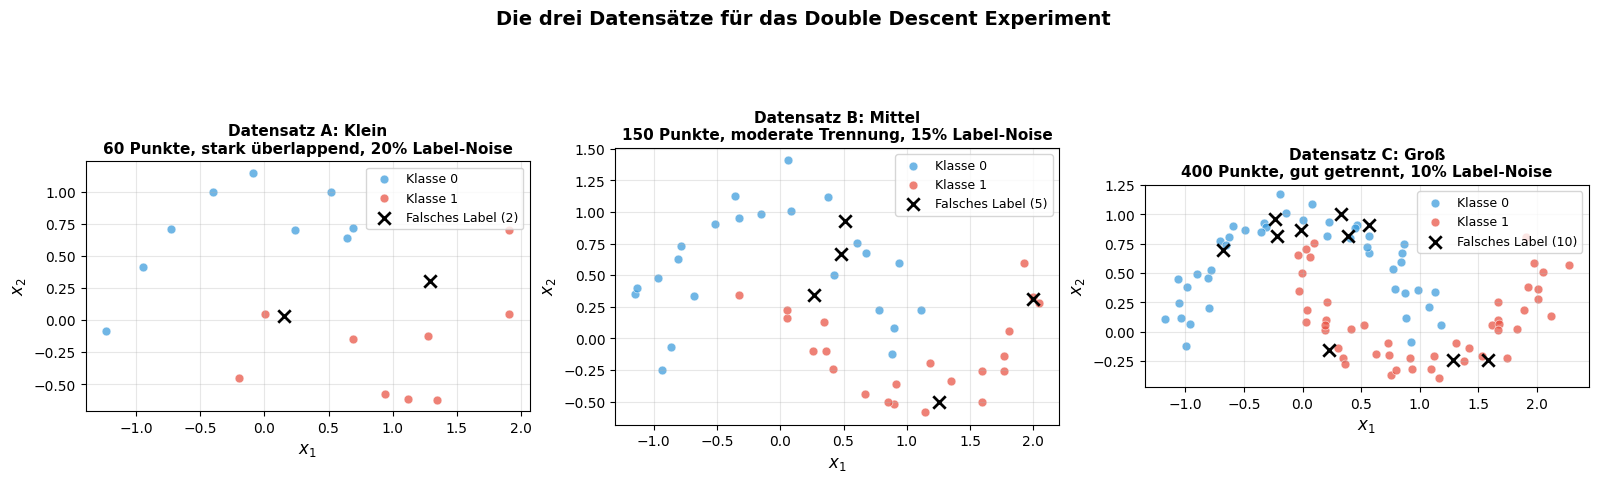


✓ Datensätze generiert und visualisiert


In [51]:
# ═══════════════════════════════════════════════════════════════════════════════
# DATENSÄTZE VISUALISIEREN
# ═══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, (key, d) in enumerate(data.items()):
    ax = axes[idx]
    cfg = d['config']
    
    X, y_noisy, y_true = d['X'], d['y_noisy'], d['y_true']
    
    # Korrekte vs. falsche Labels identifizieren
    correct_mask = y_noisy == y_true
    
    # Korrekt gelabelte Punkte
    ax.scatter(X[correct_mask & (y_noisy == 0), 0], 
               X[correct_mask & (y_noisy == 0), 1],
               c='#3498db', s=40, alpha=0.7, label='Klasse 0', edgecolors='white', linewidth=0.5)
    ax.scatter(X[correct_mask & (y_noisy == 1), 0], 
               X[correct_mask & (y_noisy == 1), 1],
               c='#e74c3c', s=40, alpha=0.7, label='Klasse 1', edgecolors='white', linewidth=0.5)
    
    # Falsch gelabelte Punkte (mit X markiert)
    wrong_mask = ~correct_mask
    ax.scatter(X[wrong_mask, 0], X[wrong_mask, 1],
               c='black', marker='x', s=80, linewidths=2, 
               label=f'Falsches Label ({wrong_mask.sum()})', zorder=5)
    
    ax.set_xlabel('$x_1$', fontsize=12)
    ax.set_ylabel('$x_2$', fontsize=12)
    ax.set_title(f"Datensatz {key}: {cfg['name']}\n{cfg['description']}", 
                 fontsize=11, fontweight='bold')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')

plt.suptitle('Die drei Datensätze für das Double Descent Experiment', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('01_datasets.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Datensätze generiert und visualisiert")

# **Modell Definition**

In [52]:
# ═══════════════════════════════════════════════════════════════════════════════
# FLEXIBLES NEURONALES NETZ
# ═══════════════════════════════════════════════════════════════════════════════

class FlexibleMLP(nn.Module):
    """
    MLP mit konfigurierbarer Architektur.
    
    Ermöglicht sehr kleine Modelle (< 15 Parameter) bis sehr große (> 10000 Parameter).
    """
    def __init__(self, hidden_sizes):
        """
        Args:
            hidden_sizes: Liste von Hidden Layer Größen, z.B. [2] oder [64, 64, 64]
        """
        super().__init__()
        
        if isinstance(hidden_sizes, int):
            hidden_sizes = [hidden_sizes]
        
        layers = []
        input_dim = 2  # 2D Input (x1, x2)
        
        for hidden_dim in hidden_sizes:
            layers.append(nn.Linear(input_dim, hidden_dim))
            layers.append(nn.ReLU())
            input_dim = hidden_dim
        
        layers.append(nn.Linear(input_dim, 1))  # Output Layer
        layers.append(nn.Sigmoid())
        
        self.network = nn.Sequential(*layers)
        self.n_params = sum(p.numel() for p in self.parameters())
        self.hidden_sizes = hidden_sizes
    
    def forward(self, x):
        return self.network(x)
    
    def __repr__(self):
        return f"MLP({self.hidden_sizes}) - {self.n_params} Parameter"

# ═══════════════════════════════════════════════════════════════════════════════
# MODELL-KONFIGURATIONEN
# ═══════════════════════════════════════════════════════════════════════════════

model_configs = [
    # Sehr kleine Modelle (< 20 Parameter)
    {'hidden': [1], 'name': 'Mini'},
    {'hidden': [2], 'name': 'Klein'},
    {'hidden': [10,10], 'name': 'moderate-Medium'},
    {'hidden': [200, 400, 200], 'name': 'XXXL-VeryDeep'},
    {'hidden': [400, 600, 1000, 600, 400], 'name': 'XXXXXL-VeryDeep'}
]

# Übersicht der Modelle
print("\n┌────────────────────────────────────────────────────────────────┐")
print("│                    MODELL-KONFIGURATIONEN                      │")
print("├────────────────────────────────────────────────────────────────┤")
print("│  Name            │ Architektur      │ Parameter               │")
print("├────────────────────────────────────────────────────────────────┤")

for cfg in model_configs:
    model = FlexibleMLP(cfg['hidden'])
    arch_str = f"2→{'→'.join(map(str, cfg['hidden']))}→1"
    print(f"│  {cfg['name']:<15} │ {arch_str:<16} │ {model.n_params:>6}                  │")

print("└────────────────────────────────────────────────────────────────┘")


┌────────────────────────────────────────────────────────────────┐
│                    MODELL-KONFIGURATIONEN                      │
├────────────────────────────────────────────────────────────────┤
│  Name            │ Architektur      │ Parameter               │
├────────────────────────────────────────────────────────────────┤
│  Mini            │ 2→1→1            │      5                  │
│  Klein           │ 2→2→1            │      9                  │
│  moderate-Medium │ 2→10→10→1        │    151                  │
│  XXXL-VeryDeep   │ 2→200→400→200→1  │ 161401                  │
│  XXXXXL-VeryDeep │ 2→400→600→1000→600→400→1 │ 1684201                  │
└────────────────────────────────────────────────────────────────┘


In [53]:
# ═══════════════════════════════════════════════════════════════════════════════
# TRAINING-FUNKTION MIT KONVERGENZ-TRACKING
# ═══════════════════════════════════════════════════════════════════════════════

def train_model(model, X_train, y_train, X_test, y_test,
                epochs=20000, lr=0.01, device=device, 
                log_interval=100, early_stop_patience=1000, 
                early_stop_delta=1e-6):
    """
    Trainiert ein Modell mit vollständigem Logging der Lernkurve.
    
    Optimiert für Apple Silicon (MPS).
    
    Returns:
        history: Dict mit train_loss, test_loss, train_acc, test_acc pro Epoche
        final_metrics: Dict mit finalen Metriken
    """
    model = model.to(device)
    
    # Daten auf Device verschieben
    X_train_t = torch.FloatTensor(X_train ).to(device)
    y_train_t = torch.FloatTensor(y_train).reshape(-1, 1).to(device)
    X_test_t = torch.FloatTensor(X_test).to(device)
    y_test_t = torch.FloatTensor(y_test).reshape(-1, 1).to(device)
    
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    # Lernkurven-Tracking
    history = {
        'epoch': [],
        'train_loss': [],
        'test_loss': [],
        'train_acc': [],
        'test_acc': []
    }
    
    # Early Stopping Tracking
    best_loss = float('inf')
    patience_counter = 0
    
    for epoch in range(epochs):
        # ─── TRAINING ───
        model.train()
        optimizer.zero_grad()
        outputs = model(X_train_t)
        loss = criterion(outputs, y_train_t)
        loss.backward()
        optimizer.step()
        
        # ─── LOGGING ───
        if epoch % log_interval == 0 or epoch == epochs - 1:
            model.eval()
            with torch.no_grad():
                train_pred = model(X_train_t)
                test_pred = model(X_test_t)
                
                train_loss = criterion(train_pred, y_train_t).item()
                test_loss = criterion(test_pred, y_test_t).item()
                train_acc = ((train_pred > 0.5) == y_train_t).float().mean().item()
                test_acc = ((test_pred > 0.5) == y_test_t).float().mean().item()
            
            history['epoch'].append(epoch)
            history['train_loss'].append(train_loss)
            history['test_loss'].append(test_loss)
            history['train_acc'].append(train_acc)
            history['test_acc'].append(test_acc)
        
        # ─── EARLY STOPPING CHECK ───
        current_loss = loss.item()
        if current_loss < best_loss - early_stop_delta:
            best_loss = current_loss
            patience_counter = 0
        else:
            patience_counter += 1
        
        if patience_counter >= early_stop_patience:
            # Finale Metriken noch loggen
            model.eval()
            with torch.no_grad():
                train_pred = model(X_train_t)
                test_pred = model(X_test_t)
                train_loss = criterion(train_pred, y_train_t).item()
                test_loss = criterion(test_pred, y_test_t).item()
                train_acc = ((train_pred > 0.5) == y_train_t).float().mean().item()
                test_acc = ((test_pred > 0.5) == y_test_t).float().mean().item()
            
            if history['epoch'][-1] != epoch:
                history['epoch'].append(epoch)
                history['train_loss'].append(train_loss)
                history['test_loss'].append(test_loss)
                history['train_acc'].append(train_acc)
                history['test_acc'].append(test_acc)
            break
    
    # Finale Metriken
    model.eval()
    with torch.no_grad():
        train_pred = model(X_train_t)
        test_pred = model(X_test_t)
        final_train_loss = criterion(train_pred, y_train_t).item()
        final_test_loss = criterion(test_pred, y_test_t).item()
        final_train_acc = ((train_pred > 0.5) == y_train_t).float().mean().item()
        final_test_acc = ((test_pred > 0.5) == y_test_t).float().mean().item()
    
    final_metrics = {
        'train_loss': final_train_loss,
        'test_loss': final_test_loss,
        'train_acc': final_train_acc,
        'test_acc': final_test_acc,
        'epochs_trained': epoch + 1,
        'converged': patience_counter >= early_stop_patience
    }
    
    # Modell zurück auf CPU für spätere Verwendung
    model = model.to('cpu')
    
    return history, final_metrics, model


def run_experiment_for_config(model_config, dataset_key, data, n_repeats=5,
                               epochs=15000, lr=0.01):
    """
    Führt Experiment für eine Modell-Konfiguration durch.
    Mehrere Wiederholungen für statistische Stabilität.
    """
    d = data[dataset_key]
    
    all_train_losses = []
    all_test_losses = []
    all_test_accs = []
    all_epochs = []
    all_histories = []
    best_model = None
    best_test_loss = float('inf')
    
    for rep in range(n_repeats):
        torch.manual_seed(rep * 100 + 42)
        model = FlexibleMLP(model_config['hidden'])
        
        history, metrics, trained_model = train_model(
            model, 
            d['X_train'], d['y_train'],
            d['X_test'], d['y_test'],
            epochs=epochs, lr=lr
        )
        
        all_train_losses.append(metrics['train_loss'])
        all_test_losses.append(metrics['test_loss'])
        all_test_accs.append(metrics['test_acc'])
        all_epochs.append(metrics['epochs_trained'])
        all_histories.append(history)
        
        if metrics['test_loss'] < best_test_loss:
            best_test_loss = metrics['test_loss']
            best_model = trained_model
    
    return {
        'config': model_config,
        'n_params': FlexibleMLP(model_config['hidden']).n_params,
        'train_loss_mean': np.mean(all_train_losses),
        'train_loss_std': np.std(all_train_losses),
        'test_loss_mean': np.mean(all_test_losses),
        'test_loss_std': np.std(all_test_losses),
        'test_acc_mean': np.mean(all_test_accs),
        'test_acc_std': np.std(all_test_accs),
        'epochs_mean': np.mean(all_epochs),
        'histories': all_histories,
        'best_model': best_model
    }

In [54]:
# ═══════════════════════════════════════════════════════════════════════════════
# HAUPTEXPERIMENT
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "═" * 70)
print("                    HAUPTEXPERIMENT STARTET")
print("═" * 70)
print(f"• Device: {device}")
print(f"• Modell-Konfigurationen: {len(model_configs)}")
print(f"• Datensätze: A, B, C")
print(f"• Wiederholungen pro Konfiguration: 5")
print(f"• Max. Epochen: 15000")
print("═" * 70)

# Ergebnisse speichern
results = {key: [] for key in data.keys()}

for dataset_key in ['A', 'B', 'C']:
    d = data[dataset_key]
    cfg = d['config']
    
    print(f"\n{'─' * 70}")
    print(f"DATENSATZ {dataset_key}: {cfg['name']}")
    print(f"Train: {d['n_train']} Punkte | Interpolation-Schwelle: ~{d['n_train']} Parameter")
    print(f"{'─' * 70}")
    
    for model_cfg in model_configs:
        result = run_experiment_for_config(
            model_cfg, dataset_key, data,
            n_repeats=5, epochs=20000, lr=0.01
        )
        results[dataset_key].append(result)
        
        # Regime bestimmen
        n_train = d['n_train']
        n_params = result['n_params']
        if n_params < n_train * 0.5:
            regime = "UNDER"
            regime_color = '\033[94m'  # Blau
        elif n_params < n_train * 1.5:
            regime = "INTERP"
            regime_color = '\033[93m'  # Gelb
        else:
            regime = "OVER"
            regime_color = '\033[92m'  # Grün
        
        reset = '\033[0m'
        
        print(f"  {model_cfg['name']:<12} ({n_params:5d}p) "
              f"[{regime_color}{regime:6s}{reset}]: "
              f"Test Loss = {result['test_loss_mean']:.4f} ± {result['test_loss_std']:.4f}, "
              f"Acc = {result['test_acc_mean']*100:.1f}%, "
              f"Epochs = {result['epochs_mean']:.0f}")

print("\n" + "═" * 70)
print("                    EXPERIMENT ABGESCHLOSSEN")
print("═" * 70)


══════════════════════════════════════════════════════════════════════
                    HAUPTEXPERIMENT STARTET
══════════════════════════════════════════════════════════════════════
• Device: mps
• Modell-Konfigurationen: 5
• Datensätze: A, B, C
• Wiederholungen pro Konfiguration: 5
• Max. Epochen: 15000
══════════════════════════════════════════════════════════════════════

──────────────────────────────────────────────────────────────────────
DATENSATZ A: Klein
Train: 16 Punkte | Interpolation-Schwelle: ~16 Parameter
──────────────────────────────────────────────────────────────────────
  Mini         (    5p) [UNDER ]: Test Loss = 6.5779 ± 9.2743, Acc = 55.0%, Epochs = 9616
  Klein        (    9p) [INTERP]: Test Loss = 20.6449 ± 8.7102, Acc = 75.0%, Epochs = 13621
  moderate-Medium (  151p) [OVER  ]: Test Loss = 16.5942 ± 10.2949, Acc = 75.0%, Epochs = 5183
  XXXL-VeryDeep (161401p) [OVER  ]: Test Loss = 25.0000 ± 0.0000, Acc = 75.0%, Epochs = 1135
  XXXXXL-VeryDeep (1684201p) 

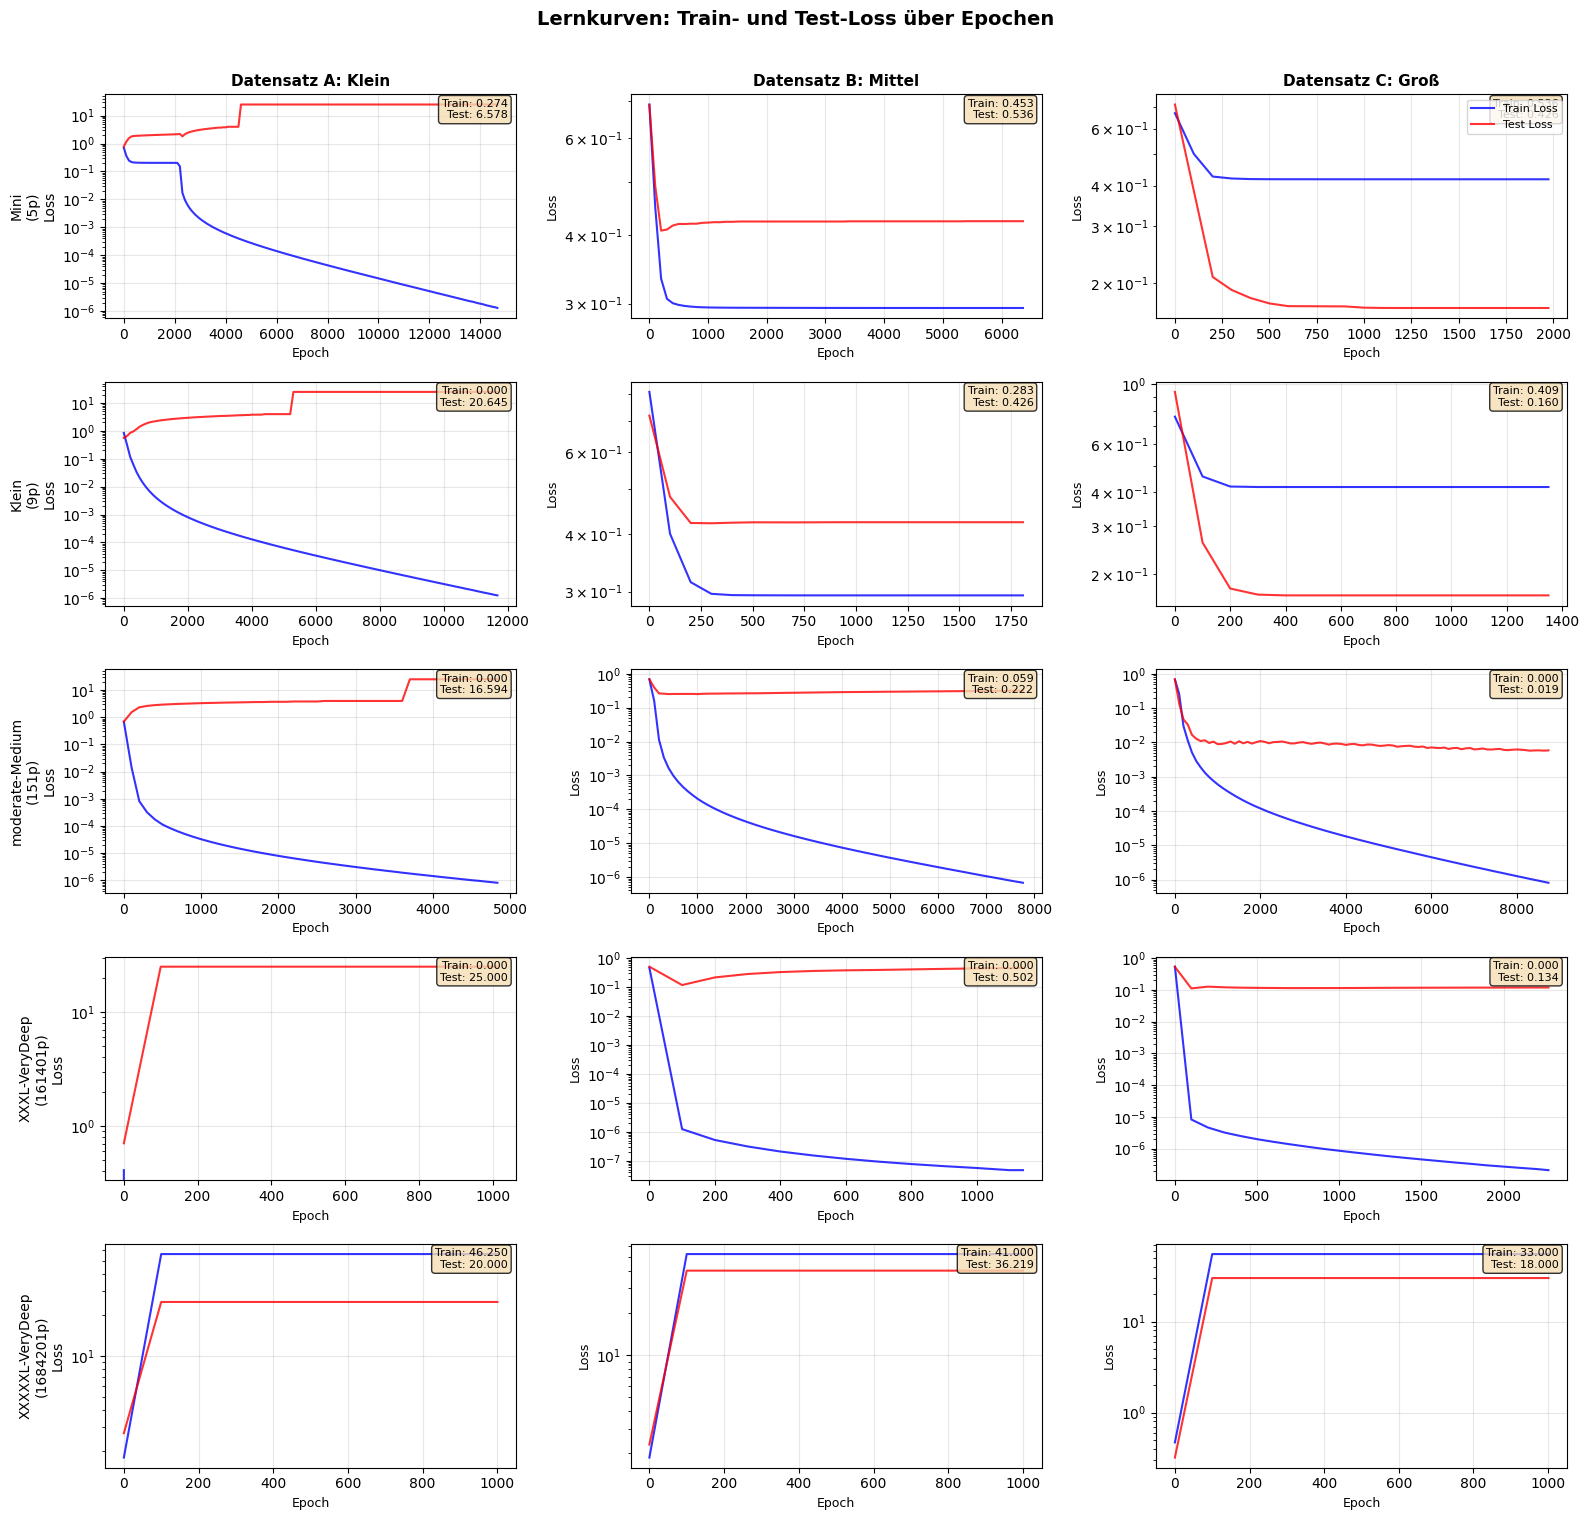

✓ Lernkurven gespeichert: 02_learning_curves.png


In [58]:
# ═══════════════════════════════════════════════════════════════════════════════
# LERNKURVEN FÜR AUSGEWÄHLTE MODELLE
# ═══════════════════════════════════════════════════════════════════════════════

selected_models = [cfg['name'] for cfg in model_configs]

fig, axes = plt.subplots(len(selected_models), 3, figsize=(16, 3*len(selected_models)))

for row_idx, model_name in enumerate(selected_models):
    # Finde das Ergebnis für dieses Modell
    model_idx = next(i for i, cfg in enumerate(model_configs) if cfg['name'] == model_name)
    
    for col_idx, dataset_key in enumerate(['A', 'B', 'C']):
        ax = axes[row_idx, col_idx]
        result = results[dataset_key][model_idx]
        
        # Erste Wiederholung plotten (repräsentativ)
        history = result['histories'][0]
        
        ax.plot(history['epoch'], history['train_loss'], 'b-', 
                label='Train Loss', linewidth=1.5, alpha=0.8)
        ax.plot(history['epoch'], history['test_loss'], 'r-', 
                label='Test Loss', linewidth=1.5, alpha=0.8)
        
        ax.set_xlabel('Epoch', fontsize=9)
        ax.set_ylabel('Loss', fontsize=9)
        ax.set_yscale('log')
        ax.grid(True, alpha=0.3)
        
        # Titel und Beschriftung
        if row_idx == 0:
            d_cfg = data[dataset_key]['config']
            ax.set_title(f"Datensatz {dataset_key}: {d_cfg['name']}", 
                        fontsize=11, fontweight='bold')
        
        if col_idx == 0:
            ax.set_ylabel(f"{model_name}\n({result['n_params']}p)\nLoss", fontsize=10)
        
        if row_idx == 0 and col_idx == 2:
            ax.legend(loc='upper right', fontsize=8)
        
        # Finale Werte annotieren
        final_train = result['train_loss_mean']
        final_test = result['test_loss_mean']
        ax.text(0.98, 0.98, f'Train: {final_train:.3f}\nTest: {final_test:.3f}',
                transform=ax.transAxes, fontsize=8, ha='right', va='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.suptitle('Lernkurven: Train- und Test-Loss über Epochen', 
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('02_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Lernkurven gespeichert: 02_learning_curves.png")

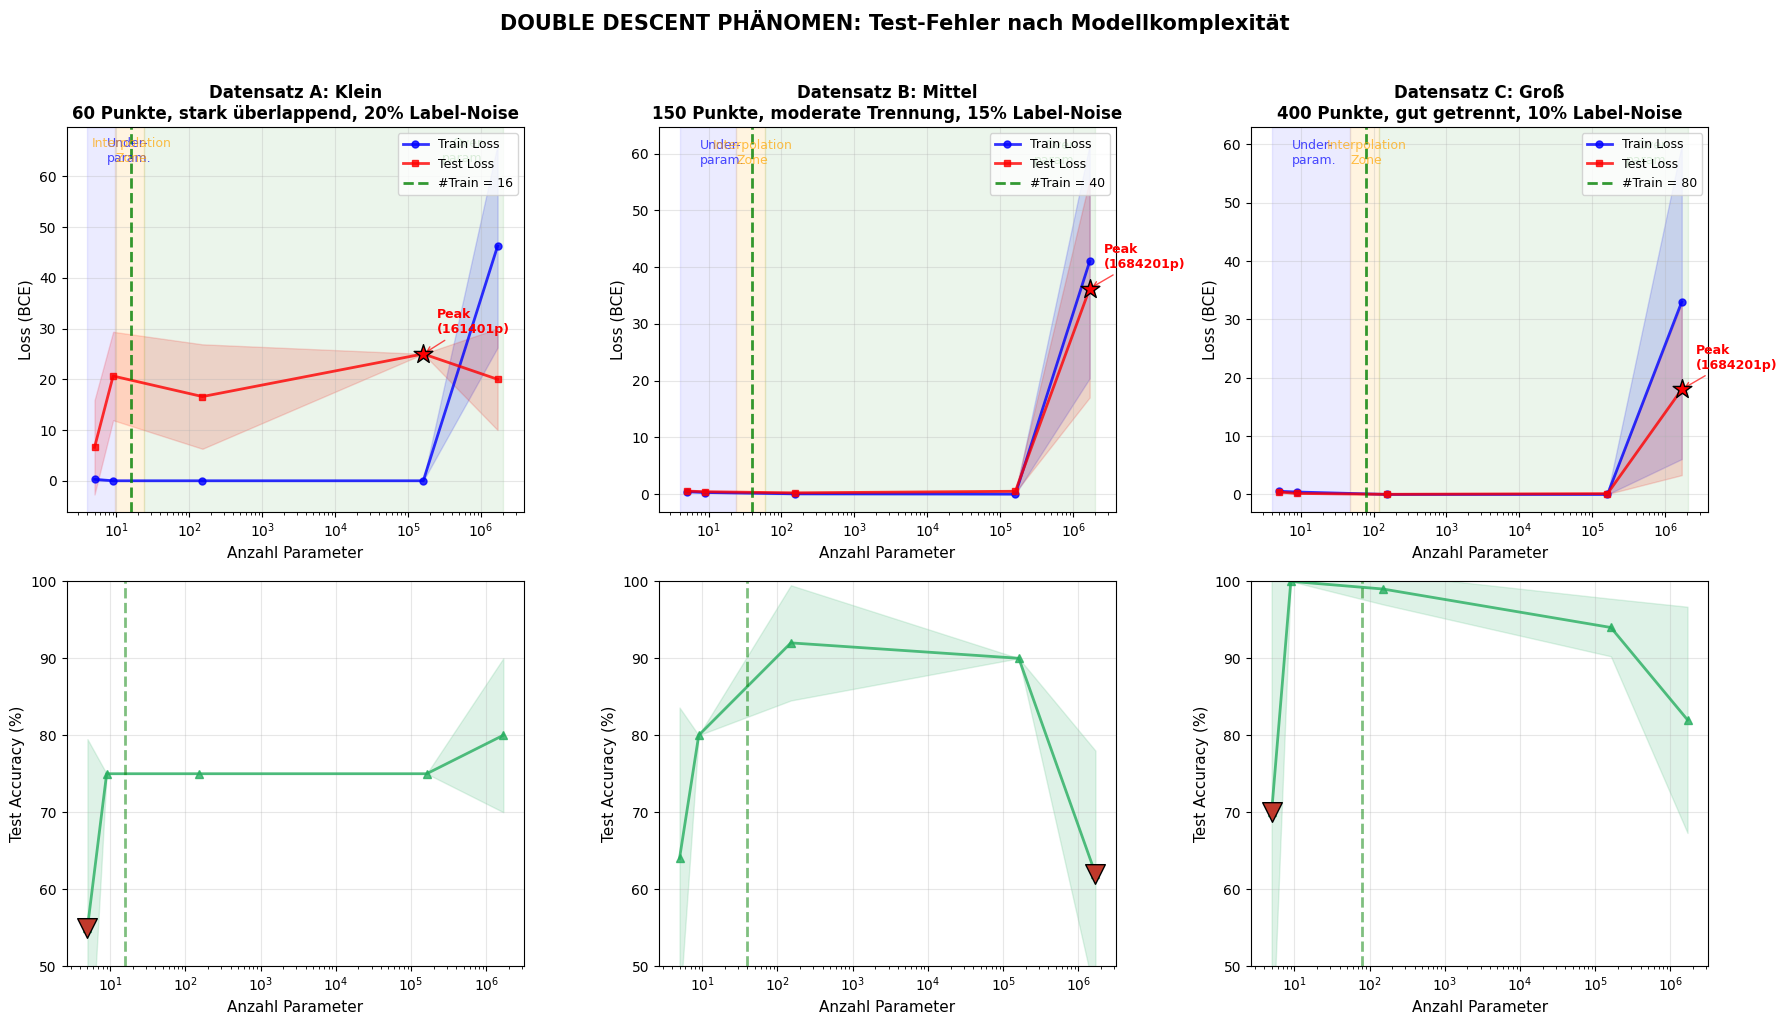

✓ Double Descent Kurven gespeichert: 03_double_descent_curves.png


In [59]:
# ═══════════════════════════════════════════════════════════════════════════════
# DOUBLE DESCENT VISUALISIERUNG
# ═══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for col_idx, dataset_key in enumerate(['A', 'B', 'C']):
    d = data[dataset_key]
    d_cfg = d['config']
    n_train = d['n_train']
    
    res = results[dataset_key]
    
    params = [r['n_params'] for r in res]
    train_loss_mean = [r['train_loss_mean'] for r in res]
    train_loss_std = [r['train_loss_std'] for r in res]
    test_loss_mean = [r['test_loss_mean'] for r in res]
    test_loss_std = [r['test_loss_std'] for r in res]
    test_acc_mean = [r['test_acc_mean'] for r in res]
    test_acc_std = [r['test_acc_std'] for r in res]
    
    # ─── OBERE REIHE: LOSS ───
    ax1 = axes[0, col_idx]
    
    # Train Loss
    ax1.plot(params, train_loss_mean, 'b-o', label='Train Loss', 
             linewidth=2, markersize=5, alpha=0.8)
    ax1.fill_between(params,
                     np.array(train_loss_mean) - np.array(train_loss_std),
                     np.array(train_loss_mean) + np.array(train_loss_std),
                     color='blue', alpha=0.15)
    
    # Test Loss
    ax1.plot(params, test_loss_mean, 'r-s', label='Test Loss', 
             linewidth=2, markersize=5, alpha=0.8)
    ax1.fill_between(params,
                     np.array(test_loss_mean) - np.array(test_loss_std),
                     np.array(test_loss_mean) + np.array(test_loss_std),
                     color='red', alpha=0.15)
    
    # Interpolation Threshold
    ax1.axvline(x=n_train, color='green', linestyle='--', linewidth=2,
                label=f'#Train = {n_train}', alpha=0.8)
    
    # Regime-Färbung
    ax1.axvspan(min(params)*0.8, n_train*0.6, alpha=0.08, color='blue')
    ax1.axvspan(n_train*0.6, n_train*1.5, alpha=0.12, color='orange')
    ax1.axvspan(n_train*1.5, max(params)*1.2, alpha=0.08, color='green') # Regime-Labels
    ax1.text(min(params)*1.5, ax1.get_ylim()[1]*0.9, 'Under-\nparam.', 
             fontsize=9, color='blue', alpha=0.7, ha='left')
    ax1.text(n_train, ax1.get_ylim()[1]*0.9, 'Interpolation\nZone', 
             fontsize=9, color='orange', alpha=0.7, ha='center')
    ax1.text(max(params)*0.7, ax1.get_ylim()[1]*0.9, 'Over-\nparam.', 
             fontsize=9, color='green', alpha=0.7, ha='right')
    
    # Peak markieren
    peak_idx = np.argmax(test_loss_mean)
    ax1.scatter([params[peak_idx]], [test_loss_mean[peak_idx]], 
                color='red', s=200, marker='*', zorder=10, edgecolors='black')
    ax1.annotate(f'Peak\n({params[peak_idx]}p)', 
                 xy=(params[peak_idx], test_loss_mean[peak_idx]),
                 xytext=(10, 15), textcoords='offset points',
                 fontsize=9, color='red', fontweight='bold',
                 arrowprops=dict(arrowstyle='->', color='red', alpha=0.7))
    
    ax1.set_xlabel('Anzahl Parameter', fontsize=11)
    ax1.set_ylabel('Loss (BCE)', fontsize=11)
    ax1.set_title(f"Datensatz {dataset_key}: {d_cfg['name']}\n{d_cfg['description']}", 
                  fontsize=12, fontweight='bold')
    ax1.set_xscale('log')
    ax1.legend(loc='upper right', fontsize=9)
    ax1.grid(True, alpha=0.3)
    
    # ─── UNTERE REIHE: ACCURACY ───
    ax2 = axes[1, col_idx]
    
    acc_pct = [a * 100 for a in test_acc_mean]
    acc_std_pct = [s * 100 for s in test_acc_std]
    
    ax2.plot(params, acc_pct, 'g-^', label='Test Accuracy', 
             linewidth=2, markersize=6, alpha=0.8, color='#27ae60')
    ax2.fill_between(params,
                     np.array(acc_pct) - np.array(acc_std_pct),
                     np.array(acc_pct) + np.array(acc_std_pct),
                     color='#27ae60', alpha=0.15)
    
    ax2.axvline(x=n_train, color='green', linestyle='--', linewidth=2, alpha=0.5)
    
    # Minimum Accuracy markieren (korrespondiert mit Peak Loss)
    min_idx = np.argmin(acc_pct)
    ax2.scatter([params[min_idx]], [acc_pct[min_idx]], 
                color='#c0392b', s=200, marker='v', zorder=10, edgecolors='black')
    
    ax2.set_xlabel('Anzahl Parameter', fontsize=11)
    ax2.set_ylabel('Test Accuracy (%)', fontsize=11)
    ax2.set_xscale('log')
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim([50, 100])

plt.suptitle('DOUBLE DESCENT PHÄNOMEN: Test-Fehler nach Modellkomplexität', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('03_double_descent_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Double Descent Kurven gespeichert: 03_double_descent_curves.png")

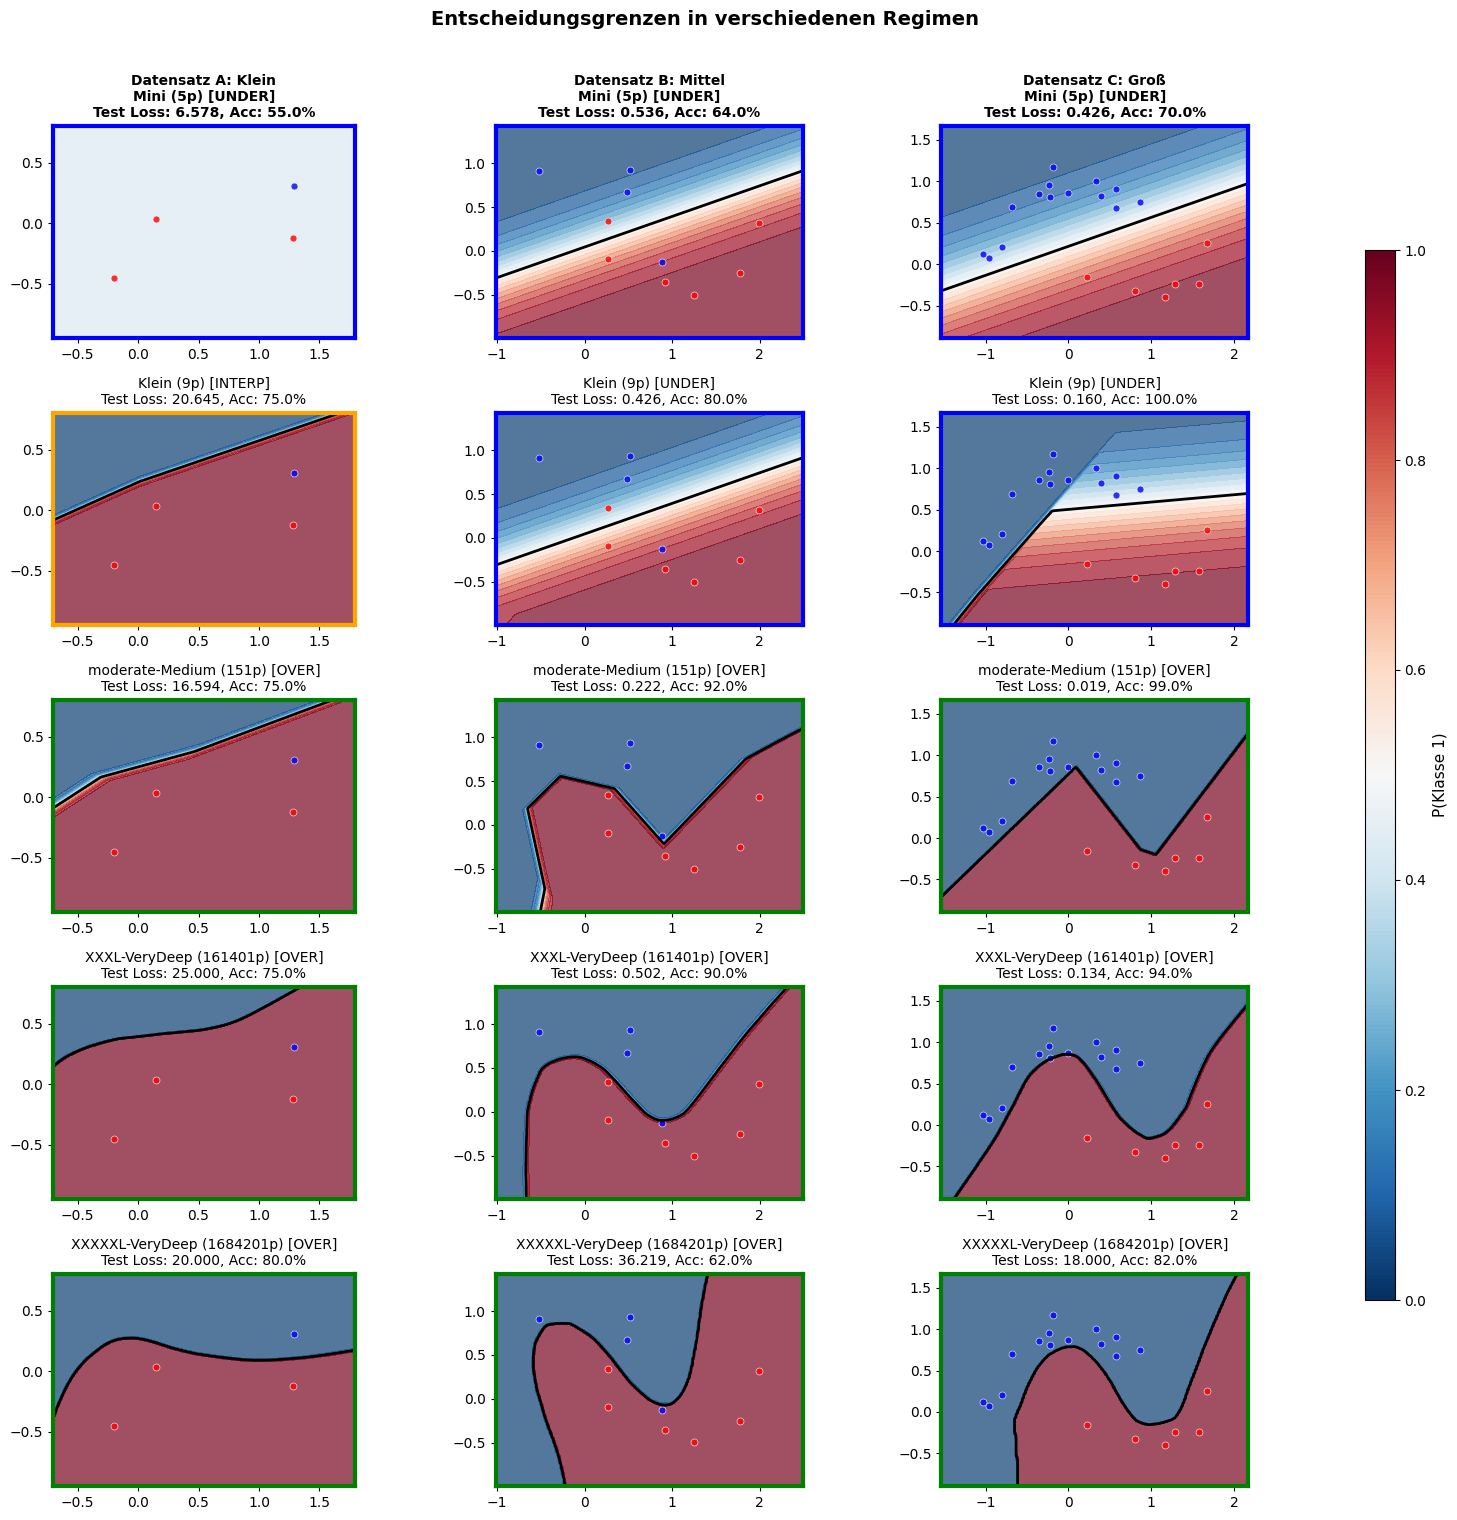

✓ Entscheidungsgrenzen gespeichert: 04_decision_boundaries.png


In [60]:
# ═══════════════════════════════════════════════════════════════════════════════
# ENTSCHEIDUNGSGRENZEN
# ═══════════════════════════════════════════════════════════════════════════════

def plot_decision_boundary(model, X, y, ax, title="", resolution=200):
    """
    Plottet die Entscheidungsgrenze eines trainierten Modells.
    """
    model.eval()
    
    # Grid erstellen
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, resolution),
                         np.linspace(y_min, y_max, resolution))
    
    grid = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)
    
    with torch.no_grad():
        Z = model(torch.FloatTensor(grid)).numpy()
    Z = Z.reshape(xx.shape)
    
    # Heatmap der Wahrscheinlichkeiten
    contour = ax.contourf(xx, yy, Z, levels=np.linspace(0, 1, 21), 
                          cmap='RdBu_r', alpha=0.7)
    
    # Entscheidungsgrenze
    ax.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)
    
    # Datenpunkte
    ax.scatter(X[y == 0, 0], X[y == 0, 1], c='blue', s=25, 
               edgecolors='white', linewidth=0.5, alpha=0.8)
    ax.scatter(X[y == 1, 0], X[y == 1, 1], c='red', s=25, 
               edgecolors='white', linewidth=0.5, alpha=0.8)
    
    ax.set_xlim([x_min, x_max])
    ax.set_ylim([y_min, y_max])
    ax.set_title(title, fontsize=10)
    ax.set_aspect('equal')
    
    return contour


# Ausgewählte Modelle für Visualisierung
viz_models = selected_models

fig, axes = plt.subplots(len(viz_models), 3, figsize=(15, 3*len(viz_models)))

for row_idx, model_name in enumerate(viz_models):
    model_idx = next(i for i, cfg in enumerate(model_configs) if cfg['name'] == model_name)
    
    for col_idx, dataset_key in enumerate(['A', 'B', 'C']):
        ax = axes[row_idx, col_idx]
        
        d = data[dataset_key]
        result = results[dataset_key][model_idx]
        model = result['best_model']
        
        # Regime bestimmen
        n_train = d['n_train']
        n_params = result['n_params']
        if n_params < n_train * 0.5:
            regime = "UNDER"
            color = 'blue'
        elif n_params < n_train * 1.5:
            regime = "INTERP"
            color = 'orange'
        else:
            regime = "OVER"
            color = 'green'
        
        # Titel
        title = f"{model_name} ({n_params}p) [{regime}]\n" \
                f"Test Loss: {result['test_loss_mean']:.3f}, Acc: {result['test_acc_mean']*100:.1f}%"
        
        contour = plot_decision_boundary(model, d['X_test'], d['y_test'], ax, title)
        
        # Zeilen/Spalten-Beschriftung
        if row_idx == 0:
            d_cfg = d['config']
            ax.set_title(f"Datensatz {dataset_key}: {d_cfg['name']}\n" + title, 
                        fontsize=10, fontweight='bold')
        
        # Rahmenfarbe nach Regime
        for spine in ax.spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(3)

# Colorbar hinzufügen
fig.subplots_adjust(right=0.92)
cbar_ax = fig.add_axes([0.94, 0.15, 0.02, 0.7])
sm = plt.cm.ScalarMappable(cmap='RdBu_r', norm=plt.Normalize(0, 1))
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('P(Klasse 1)', fontsize=11)

plt.suptitle('Entscheidungsgrenzen in verschiedenen Regimen', 
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(rect=[0, 0, 0.92, 1])
plt.savefig('04_decision_boundaries.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Entscheidungsgrenzen gespeichert: 04_decision_boundaries.png")